In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('26-customer_data.csv')

In [3]:
df.head()

# scale edilmiş bir data. Annual_Income -> yıllık gelir , Spending_Score -> Harcama Skoru

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


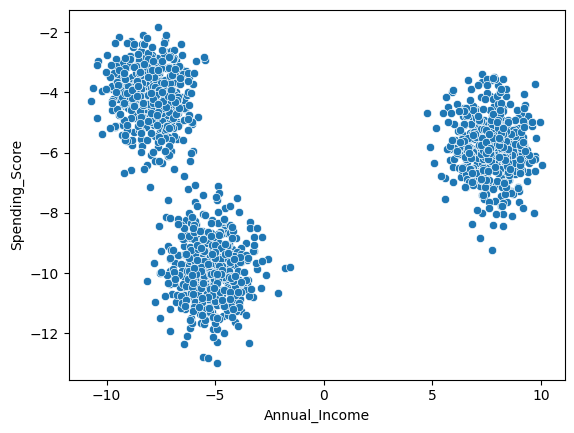

In [5]:
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
# Burası önemli
# elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[198.30484840154998,
 69.32365724252244,
 11.77378789786942,
 9.97792990314424,
 8.225999866448403,
 7.27924993770809,
 5.523701237993979,
 5.028293322234426,
 4.471672377408503,
 4.076406509333343]

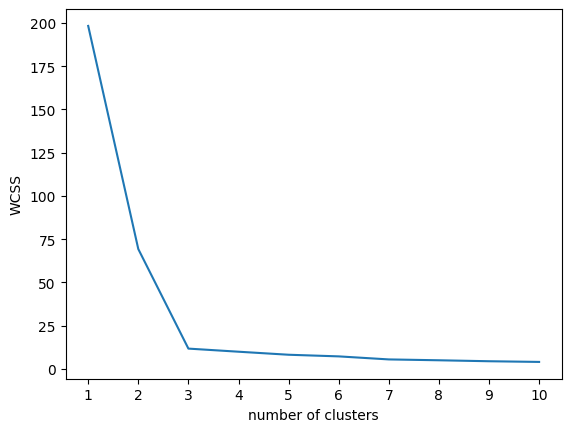

In [12]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3)

In [14]:
kmeans.fit(X_train_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [15]:
y_pred = kmeans.predict(X_test_scaled)

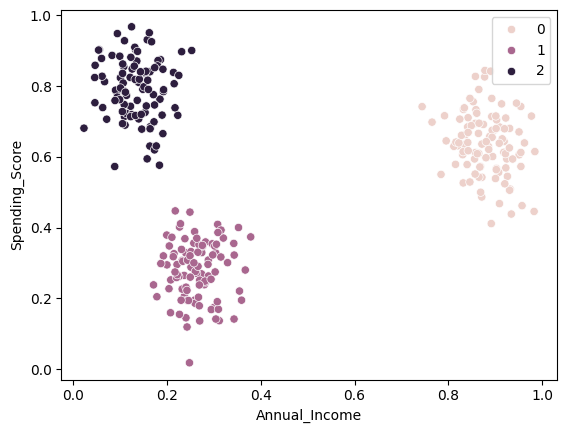

In [16]:
sns.scatterplot(data=pd.DataFrame(X_test_scaled, columns=X_test.columns), x="Annual_Income", y="Spending_Score", hue=y_pred)
plt.show()

In [17]:
from kneed import KneeLocator

In [18]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [19]:
kl.elbow

np.int64(3)

In [20]:
# silhoutte score

In [21]:
from sklearn.metrics import silhouette_score

In [22]:
silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_scores.append(score)

In [23]:
silhouette_scores

[0.653040525405795,
 0.7860072644571928,
 0.6382228570167756,
 0.4965440134548949,
 0.5169276633305887,
 0.37268646550399187,
 0.3582431275188108,
 0.36086370903636455,
 0.34640838818003716]

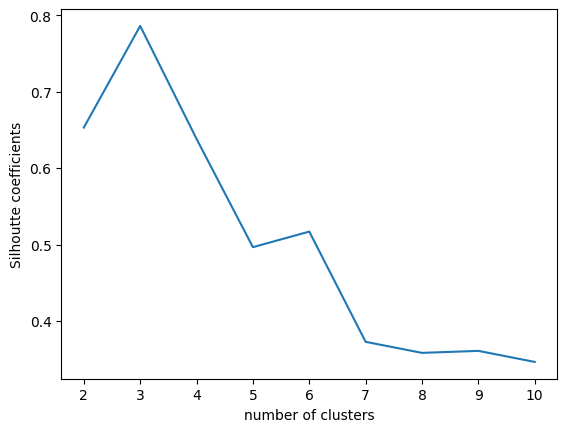

In [24]:
plt.plot(range(2,11), silhouette_scores)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("Silhoutte coefficients")
plt.show()